# Potts model
Step 1: Define Q states with values 1, 2, ..., Q.

Step 2: Initialize the starting configuration:

+ Cold: All spins set to 1.

+ Random: Each spin randomly assigned a value from 1 to Q with uniform distribution.

Step 3: Run the Metropolis and Wolff cluster algorithms for the Potts model, similar to the Ising model.

For spin flips, propose a new, different random value from 1 to Q.

Formulas to compute energy and magnetization:

+ Energy: $$ E= - \sum_{<i,j>} \delta_{s_i s_j}$$
where $<i,j>$ denotes neighboring pairs.

+ Magnetization: 
$$ M = \dfrac{Q}{Q-1} \bigl( \dfrac{N_{max}}{N^2} - \dfrac{1}{Q}\bigr)$$
where $N$ is the lattice size, $N_{max}$  is the count of the most frequent spin state in the lattice. 

# Task
Plot magnetization and energy of Potts model as a function of $\beta$ near $\beta_c = \ln(1+ \sqrt{Q})$ using Metropolis and Wolff cluster.

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
Q = 3                              # number of Potts states
N = 16                             # lattice side, so we have N*N spins
beta_c = np.log(1.0 + np.sqrt(Q))  # critical inverse temperature
print(f"Q = {Q}, lattice {N}x{N}, beta_c = {beta_c:.4f}")

Q = 3, lattice 16x16, beta_c = 1.0051


### Lattice, energy and magnetization

Same `np.roll` trick as in the Ising notebooks, but now the bond contribution is the Kronecker delta $\mathbb{1}[s_i = s_j]$ instead of $s_i s_j$. For the magnetization I just count how many sites carry each value, take the largest count $N_{\max}$, and plug into the formula given in the task.

In [44]:
def init_lattice(N, Q, start="random"):
    if start == "cold":
        return np.ones((N, N), dtype=np.int8)
    else:
        return np.random.randint(1, Q + 1, size=(N, N)).astype(np.int8)


def total_energy(spins):
    # compare each site to its right and down neighbour (each bond counted once)
    right = np.roll(spins, -1, axis=1)
    down  = np.roll(spins, -1, axis=0)
    same_bonds = np.sum(spins == right) + np.sum(spins == down)
    return -float(same_bonds)


def magnetization(spins, Q):
    counts = np.bincount(spins.ravel(), minlength=Q + 1)
    N_max = counts.max()
    N2 = spins.size
    return (Q / (Q - 1.0)) * (N_max / N2 - 1.0 / Q)


# test:
test = init_lattice(N, Q, start="cold")
print("cold start: E =", total_energy(test), " (should be -2*N*N =", -2*N*N, ")")
print("cold start: M =", magnetization(test, Q), " (should be 1.0)")

test = init_lattice(N, Q, start="random")
print("random start: E =", total_energy(test),
      " (should be ~", -2*N*N/Q, ")")
print("random start: M =", round(magnetization(test, Q), 3),
      " (should be close to 0)")

cold start: E = -512.0  (should be -2*N*N = -512 )
cold start: M = 1.0  (should be 1.0)
random start: E = -165.0  (should be ~ -170.66666666666666 )
random start: M = 0.004  (should be close to 0)


### Metropolis for the Potts model

Same Metropolis as for Ising — only two things change:

- the proposal: pick $s_\text{new}$ uniformly from the other $Q-1$ values
- the energy difference becomes $\Delta E = n_\text{old} - n_\text{new}$, where $n_\text{old}$ ($n_\text{new}$) is the number of neighbours equal to $s_\text{old}$ ($s_\text{new}$)

In [45]:
def metropolis_sweep(spins, beta, Q):
    N = spins.shape[0]
    # pre-draw all random numbers for one sweep
    rand_i  = np.random.randint(0, N, size=N * N)
    rand_j  = np.random.randint(0, N, size=N * N)
    rand_s  = np.random.randint(1, Q,  size=N * N)   # values 1..Q-1
    rand_u  = np.random.random(size=N * N)

    for k in range(N * N):
        i = rand_i[k]
        j = rand_j[k]
        s_old = spins[i, j]

        # turn a value in 1..Q-1 into a value in {1..Q} \ {s_old} by shifting
        s_new = rand_s[k]
        if s_new >= s_old:
            s_new += 1

        # count neighbours matching the old and new value (with PBC)
        n_old = 0
        n_new = 0
        for di, dj in ((-1, 0), (1, 0), (0, -1), (0, 1)):
            sn = spins[(i + di) % N, (j + dj) % N]
            if sn == s_old:
                n_old += 1
            if sn == s_new:
                n_new += 1
        dE = n_old - n_new

        # accept/reject
        if dE <= 0 or rand_u[k] < np.exp(-beta * dE):
            spins[i, j] = s_new
    return spins

### Wolff cluster for the Potts model

Same idea as the Ising Wolff. The Potts-specific parts are:

- a neighbour can only be added if it has the **same value** as the seed (bonds between different values do not exist)
- the bond probability is $p_\text{add} = 1 - e^{-\beta J} = 1 - e^{-\beta}$ for $J=1$. There is **no factor of 2** compared to Ising
- the cluster is reassigned to a **new value** chosen uniformly from the other $Q-1$ values

In [46]:
def wolff_step(spins, beta, Q):
    N = spins.shape[0]
    p_add = 1.0 - np.exp(-beta)

    # pick seed
    i0 = np.random.randint(N)
    j0 = np.random.randint(N)
    s_old = spins[i0, j0]

    # pick a new value different from s_old
    s_new = np.random.randint(1, Q)
    if s_new >= s_old:
        s_new += 1

    # iterative cluster growth
    in_cluster = np.zeros_like(spins, dtype=bool)
    in_cluster[i0, j0] = True
    stack = [(i0, j0)]

    while stack:
        i, j = stack.pop()
        for di, dj in ((-1, 0), (1, 0), (0, -1), (0, 1)):
            ni = (i + di) % N
            nj = (j + dj) % N
            # only accept if same value AND not in cluster yet
            if not in_cluster[ni, nj] and spins[ni, nj] == s_old:
                if np.random.random() < p_add:
                    in_cluster[ni, nj] = True
                    stack.append((ni, nj))

    # flip the whole cluster in one shot
    spins[in_cluster] = s_new
    return int(in_cluster.sum())

### Running the simulation

Same burn-in + measurement structure as before. A few Potts-specific choices:

- random (hot) start at every $\beta$; the cold start is implemented in `init_lattice` too
- I report energy **per site** ($E/N^2$)
- fewer Wolff updates than Metropolis sweeps, because one Wolff step flips many spins at once

In [47]:
# range of beta values around beta_c
betas = np.linspace(0.70, 1.30, 16)

# how many updates we do
n_therm_metro  = 200       # thermalization sweeps for Metropolis
n_meas_metro   = 800       # measurement sweeps for Metropolis
n_therm_wolff  = 50        # thermalization cluster flips for Wolff
n_meas_wolff   = 400       # measurement cluster flips for Wolff

# storage for averages
E_metro = np.zeros_like(betas)
M_metro = np.zeros_like(betas)
E_wolff = np.zeros_like(betas)
M_wolff = np.zeros_like(betas)

for idx, beta in enumerate(betas):

    # ---------- Metropolis ----------
    spins = init_lattice(N, Q, start="random")
    for _ in range(n_therm_metro):
        metropolis_sweep(spins, beta, Q)
    E_sum, M_sum = 0.0, 0.0
    for _ in range(n_meas_metro):
        metropolis_sweep(spins, beta, Q)
        E_sum += total_energy(spins)
        M_sum += magnetization(spins, Q)
    E_metro[idx] = E_sum / n_meas_metro / (N * N)   # energy per site
    M_metro[idx] = M_sum / n_meas_metro

    # ---------- Wolff ----------
    spins = init_lattice(N, Q, start="random")
    for _ in range(n_therm_wolff):
        wolff_step(spins, beta, Q)
    E_sum, M_sum = 0.0, 0.0
    for _ in range(n_meas_wolff):
        wolff_step(spins, beta, Q)
        E_sum += total_energy(spins)
        M_sum += magnetization(spins, Q)
    E_wolff[idx] = E_sum / n_meas_wolff / (N * N)
    M_wolff[idx] = M_sum / n_meas_wolff

    print(f"beta = {beta:.3f} | "
          f"Metro: E/N^2 = {E_metro[idx]:+.3f}, M = {M_metro[idx]:.3f} | "
          f"Wolff: E/N^2 = {E_wolff[idx]:+.3f}, M = {M_wolff[idx]:.3f}")

beta = 0.700 | Metro: E/N^2 = -1.062, M = 0.100 | Wolff: E/N^2 = -1.028, M = 0.099
beta = 0.740 | Metro: E/N^2 = -1.098, M = 0.115 | Wolff: E/N^2 = -1.110, M = 0.114
beta = 0.780 | Metro: E/N^2 = -1.140, M = 0.145 | Wolff: E/N^2 = -1.061, M = 0.125
beta = 0.820 | Metro: E/N^2 = -1.189, M = 0.165 | Wolff: E/N^2 = -1.128, M = 0.145
beta = 0.860 | Metro: E/N^2 = -1.244, M = 0.234 | Wolff: E/N^2 = -1.258, M = 0.204
beta = 0.900 | Metro: E/N^2 = -1.277, M = 0.208 | Wolff: E/N^2 = -1.245, M = 0.210
beta = 0.940 | Metro: E/N^2 = -1.393, M = 0.423 | Wolff: E/N^2 = -1.348, M = 0.308
beta = 0.980 | Metro: E/N^2 = -1.427, M = 0.353 | Wolff: E/N^2 = -1.527, M = 0.588
beta = 1.020 | Metro: E/N^2 = -1.668, M = 0.780 | Wolff: E/N^2 = -1.649, M = 0.741
beta = 1.060 | Metro: E/N^2 = -1.765, M = 0.866 | Wolff: E/N^2 = -1.745, M = 0.851
beta = 1.100 | Metro: E/N^2 = -1.819, M = 0.911 | Wolff: E/N^2 = -1.810, M = 0.904
beta = 1.140 | Metro: E/N^2 = -1.846, M = 0.908 | Wolff: E/N^2 = -1.856, M = 0.932
beta

### Plots

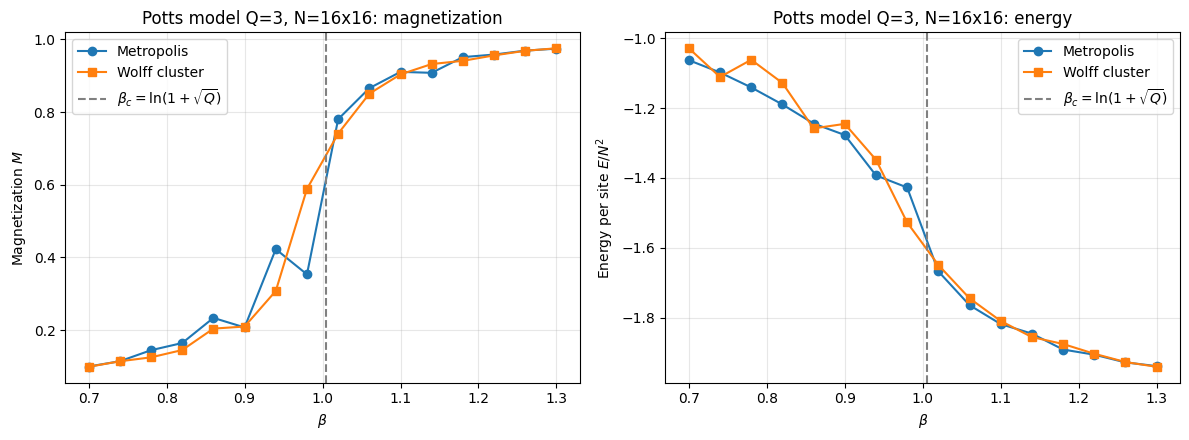

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(betas, M_metro, "o-", label="Metropolis")
axes[0].plot(betas, M_wolff, "s-", label="Wolff cluster")
axes[0].axvline(beta_c, ls="--", color="gray", label=r"$\beta_c=\ln(1+\sqrt{Q})$")
axes[0].set_xlabel(r"$\beta$")
axes[0].set_ylabel("Magnetization $M$")
axes[0].set_title(f"Potts model Q={Q}, N={N}x{N}: magnetization")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(betas, E_metro, "o-", label="Metropolis")
axes[1].plot(betas, E_wolff, "s-", label="Wolff cluster")
axes[1].axvline(beta_c, ls="--", color="gray", label=r"$\beta_c=\ln(1+\sqrt{Q})$")
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel(r"Energy per site $E/N^2$")
axes[1].set_title(f"Potts model Q={Q}, N={N}x{N}: energy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### What the plots tell us

- For $\beta < \beta_c$: $M$ stays small (about $0.1$ at $\beta = 0.7$, not exactly $0$ because $N_{\max}$ fluctuates on a finite lattice), and $E/N^2 \approx -1.05$ — already well below the trivial high-$T$ value $-2/Q \approx -0.67$, which only applies for $\beta \to 0$.

- For $\beta > \beta_c$: at $\beta = 1.3$ both algorithms give $M \approx 0.97$ and $E/N^2 \approx -1.94$, close to the ordered limits $M = 1$ and $E/N^2 = -2$.

- The big change in both curves happens right around the dashed line $\beta_c = \ln(1+\sqrt{Q})$, as expected. The transition is rounded because $N=16$ is small.